In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pyDOE2 import lhs
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [4]:
def beam_deflection(F, L, E, I):
    """
    Cantilever beam tip deflection formula.
    
    Parameters:
    -----------
    F : Force at tip (N) — range: 100 to 1000 N
    L : Beam length (m) — range: 0.5 to 2.0 m
    E : Young's modulus (Pa) — range: 70e9 to 210e9 Pa
    I : Second moment of area (m^4) — range: 1e-7 to 1e-5 m^4
    
    Returns:
    --------
    delta : Tip deflection (m)
    """
    delta = (F * L**3) / (3 * E * I)
    return delta

# Sanity check with realistic values
# Steel beam, 1m long, 500N force
F_test = 500          # N
L_test = 1.0          # m
E_test = 200e9        # Pa (steel)
I_test = 1e-6         # m^4

delta_test = beam_deflection(F_test, L_test, E_test, I_test)
print(f"Test deflection: {delta_test*1000:.4f} mm")
print()
print("Physical check:")
print(f"  Longer beam → more deflection ✓ (L is cubed in formula)")
print(f"  Stiffer material → less deflection ✓ (E is in denominator)")
print(f"  Bigger force → more deflection ✓ (F is in numerator)")

Test deflection: 0.8333 mm

Physical check:
  Longer beam → more deflection ✓ (L is cubed in formula)
  Stiffer material → less deflection ✓ (E is in denominator)
  Bigger force → more deflection ✓ (F is in numerator)


In [5]:
# 4 input variables this time, 30 samples
n_samples = 80
n_vars = 4

# Latin Hypercube Sampling in [0,1] space
lhs_samples = lhs(n_vars, samples=n_samples, criterion='maximin')

# Scale each variable to its physical range
X = np.zeros((n_samples, n_vars))
X[:, 0] = lhs_samples[:, 0] * (1000 - 100) + 100      # F: 100-1000 N
X[:, 1] = lhs_samples[:, 1] * (2.0 - 0.5) + 0.5       # L: 0.5-2.0 m
X[:, 2] = lhs_samples[:, 2] * (210e9 - 70e9) + 70e9   # E: 70-210 GPa
X[:, 3] = lhs_samples[:, 3] * (1e-5 - 1e-7) + 1e-7    # I: 1e-7 to 1e-5 m^4

# Evaluate the "simulation" at all 30 points
y = np.array([beam_deflection(X[i,0], X[i,1], X[i,2], X[i,3]) 
              for i in range(n_samples)])

print(f"Sample points shape: {X.shape}")
print(f"Output shape: {y.shape}")
print()
print("Input ranges in our samples:")
print(f"  F: {X[:,0].min():.1f} to {X[:,0].max():.1f} N")
print(f"  L: {X[:,1].min():.3f} to {X[:,1].max():.3f} m")
print(f"  E: {X[:,2].min():.2e} to {X[:,2].max():.2e} Pa")
print(f"  I: {X[:,3].min():.2e} to {X[:,3].max():.2e} m^4")
print()
print(f"Deflection range: {y.min()*1000:.4f} to {y.max()*1000:.2f} mm")

Sample points shape: (80, 4)
Output shape: (80,)

Input ranges in our samples:
  F: 100.3 to 998.5 N
  L: 0.513 to 1.995 m
  E: 7.02e+10 to 2.09e+11 Pa
  I: 1.75e-07 to 1.00e-05 m^4

Deflection range: 0.0293 to 19.57 mm


In [6]:
# Log-transform E and I before scaling
# because they span orders of magnitude
X_log = X.copy()
X_log[:, 2] = np.log(X[:, 2])  # log(E)
X_log[:, 3] = np.log(X[:, 3])  # log(I)

# Scale all inputs to same range
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Log-transform the output too
y_log = np.log(y)

# Define kernel - one length scale per input variable
kernel = C(1.0) * RBF(length_scale=np.ones(n_vars))

# Create and train the GP
gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=15,
    normalize_y=True,
    alpha=1e-6
)

gp.fit(X_scaled, y_log)

print("GP trained successfully!")
print(f"Optimized kernel: {gp.kernel_}")
print()
print("Trained on log(E), log(I), and log(deflection)")
print("Standard scaling applied after log-transform")

GP trained successfully!
Optimized kernel: 108**2 * RBF(length_scale=[3.04, 6.23, 946, 376])

Trained on log(E), log(I), and log(deflection)
Standard scaling applied after log-transform


/Users/triashasarkar/Documents/GitHub/Surrogate-model-learning/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


In [7]:
# Generate 500 random test points the GP has never seen
np.random.seed(42)
n_test = 500

X_test = np.zeros((n_test, n_vars))
X_test[:, 0] = np.random.uniform(100, 1000, n_test)    # F
X_test[:, 1] = np.random.uniform(0.5, 2.0, n_test)    # L
X_test[:, 2] = np.random.uniform(70e9, 210e9, n_test)  # E
X_test[:, 3] = np.random.uniform(1e-7, 1e-5, n_test)   # I

# True deflection at test points
y_test_true = np.array([beam_deflection(X_test[i,0], X_test[i,1],
                                         X_test[i,2], X_test[i,3])
                         for i in range(n_test)])

# Apply same log-transform to test inputs before scaling
X_test_log = X_test.copy()
X_test_log[:, 2] = np.log(X_test[:, 2])  # log(E)
X_test_log[:, 3] = np.log(X_test[:, 3])  # log(I)
X_test_scaled = scaler.transform(X_test_log)

# GP prediction in log space, convert back
y_test_log_pred, y_test_std = gp.predict(X_test_scaled, return_std=True)
y_test_pred = np.exp(y_test_log_pred)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
r2   = r2_score(y_test_true, y_test_pred)
mape = np.mean(np.abs((y_test_true - y_test_pred) / y_test_true)) * 100

print("=" * 45)
print("   Beam Deflection Surrogate Performance")
print("=" * 45)
print(f"  R²   : {r2:.4f}")
print(f"  RMSE : {rmse*1000:.6f} mm")
print(f"  MAPE : {mape:.2f}%")
print()
print(f"  Tested on {n_test} unseen points")
print(f"  Trained on {n_samples} simulation runs")
print()
if r2 > 0.99:
    print("  Excellent! Near-perfect surrogate.")
elif r2 > 0.95:
    print("  Great fit - very usable surrogate.")
elif r2 > 0.85:
    print("  Good fit - reasonable approximation.")
else:
    print("  Moderate fit - check plots for clues.")
print("=" * 45)

   Beam Deflection Surrogate Performance
  R²   : 1.0000
  RMSE : 0.010409 mm
  MAPE : 0.26%

  Tested on 500 unseen points
  Trained on 80 simulation runs

  Excellent! Near-perfect surrogate.


/Users/triashasarkar/Documents/GitHub/Surrogate-model-learning/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: divide by zero encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/triashasarkar/Documents/GitHub/Surrogate-model-learning/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: overflow encountered in matmul
  y_mean = K_trans @ self.alpha_
/Users/triashasarkar/Documents/GitHub/Surrogate-model-learning/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/_gpr.py:441: RuntimeWarning: invalid value encountered in matmul
  y_mean = K_trans @ self.alpha_


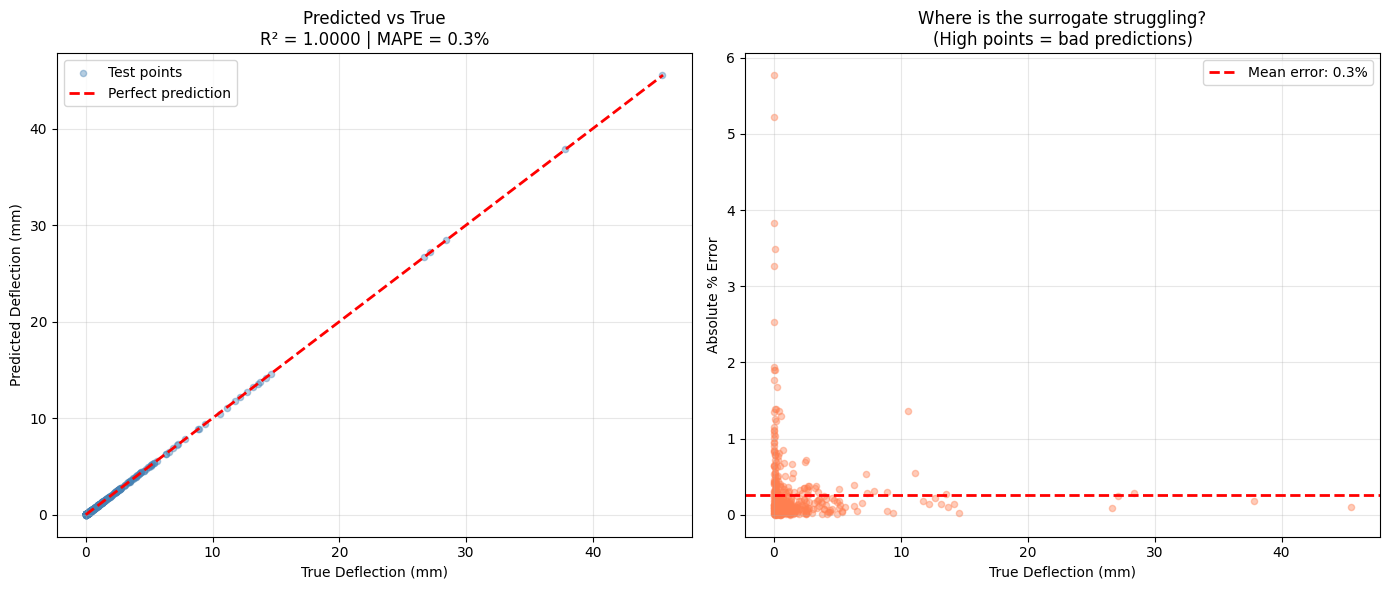


Look at Plot 2 carefully:
If errors are highest at small deflections → sparse sampling issue
If errors are spread randomly → need more training points overall


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Predicted vs True deflection
axes[0].scatter(y_test_true * 1000, y_test_pred * 1000,
                alpha=0.4, s=20, color='steelblue', label='Test points')
max_val = max(y_test_true.max(), y_test_pred.max()) * 1000
axes[0].plot([0, max_val], [0, max_val], 'r--', 
             linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('True Deflection (mm)')
axes[0].set_ylabel('Predicted Deflection (mm)')
axes[0].set_title(f'Predicted vs True\nR² = {r2:.4f} | MAPE = {mape:.1f}%')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Error vs true deflection
# Shows WHERE the surrogate struggles most
errors = np.abs((y_test_true - y_test_pred) / y_test_true) * 100
axes[1].scatter(y_test_true * 1000, errors,
                alpha=0.4, s=20, color='coral')
axes[1].axhline(y=mape, color='red', linestyle='--', 
                linewidth=2, label=f'Mean error: {mape:.1f}%')
axes[1].set_xlabel('True Deflection (mm)')
axes[1].set_ylabel('Absolute % Error')
axes[1].set_title('Where is the surrogate struggling?\n(High points = bad predictions)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/beam_deflection_30samples.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("\nLook at Plot 2 carefully:")
print("If errors are highest at small deflections → sparse sampling issue")
print("If errors are spread randomly → need more training points overall")